In [1]:
import os
import json
import random
import itertools
import warnings
from tqdm.auto import tqdm
from tabulate import tabulate

import torch
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

from models import ImageClassificationModel, get_model
from data import MNISTDataset, get_dataset
from utils.plot import *
from xai import *
from metrics import *

# plt.rcParams["font.size"] = 24
# plt.rcParams["font.family"] = "cmr10"

[nltk_data] Downloading package punkt_tab to /home/xia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
device = "cuda:7"
model_dir = "/home/xia/claim-xai/configs/imagenette/base"
model_config = json.load( open(os.path.join(model_dir, "config.json"), "r") )
model_metadata = json.load( open(os.path.join(model_dir, "masker/_metadata.json"), "r") )

In [3]:
ds_train, ds_val, ds_test, num_classes = get_dataset(
    model_config["dataset_name"], 
    data_dir = "../_datasets", 
    splits = ["train", "validation", "test"],
    **model_config["dataset_args"], 
)


model = get_model(
    model_name = model_config["model_name"],
    checkpoint_path = os.path.join(model_dir, model_metadata["best_checkpoint"]),
    **model_config["model_args"]
).eval().to(device)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


---

torch.Size([1, 1, 224, 224])
tensor(1.) tensor(0.)
pred=1 label=1


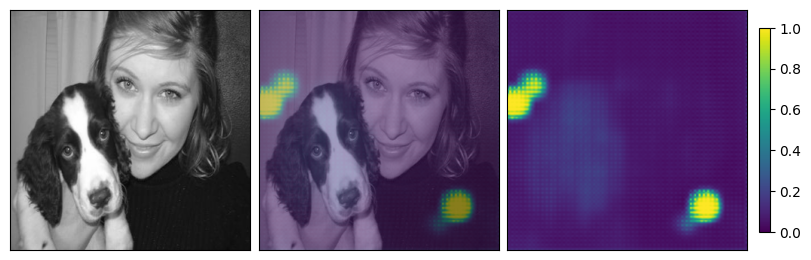

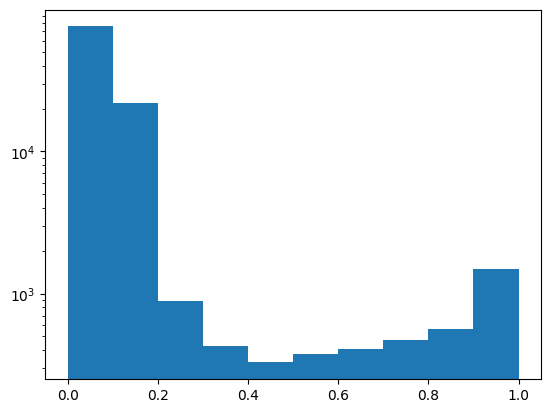

In [4]:
in_image, label = ds_test[0]

with torch.no_grad():
    inputs = model.preprocess(in_image.unsqueeze(0))
    logits, weights = model(inputs)

print(weights.shape)

image_plot = in_image.cpu()
weights_plot = weights[0].cpu()
weights_plot = torchvision.transforms.functional.resize(weights_plot, (image_plot.shape[1], image_plot.shape[2]), interpolation=torchvision.transforms.InterpolationMode.BILINEAR)
weights_plot = (weights_plot - weights_plot.min()) / (weights_plot.max() - weights_plot.min())


print(weights_plot.max(), weights_plot.min())
print(f"pred={torch.argmax(logits).item()} label={label}")


plot_image_attribution(image_plot, weights_plot)
plt.show()


plt.hist(weights_plot.flatten())
plt.yscale("log")
plt.show()

---

pred=1 label=1


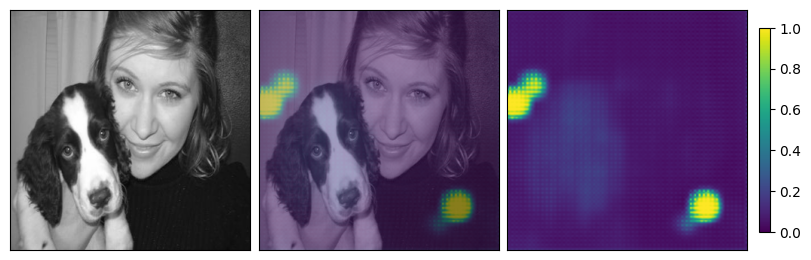

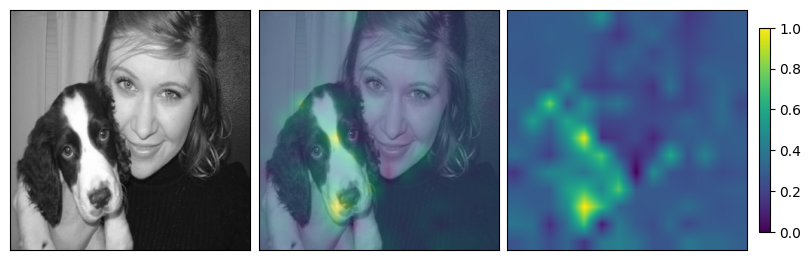

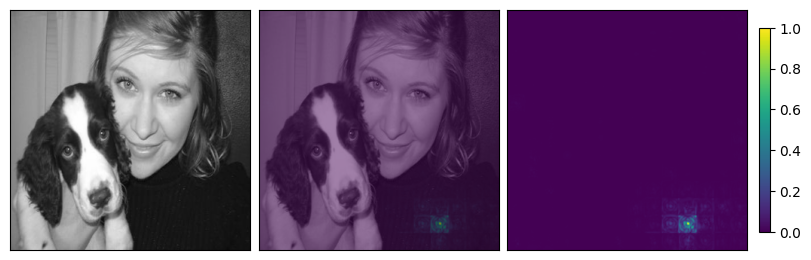

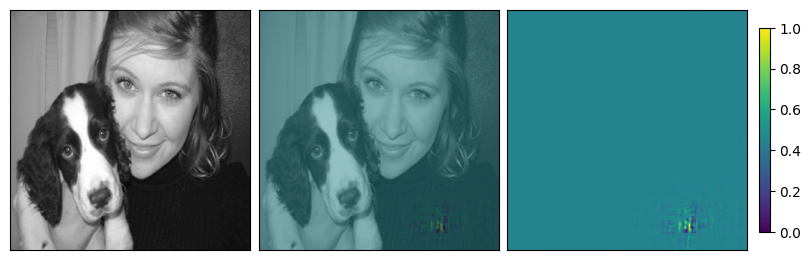

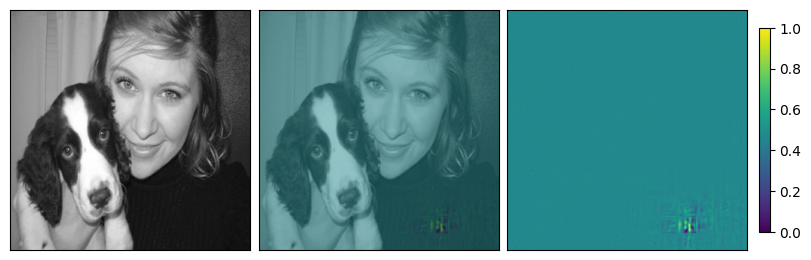

In [5]:
in_image, label = ds_test[0]

with torch.no_grad():
    inputs = model.preprocess(in_image.unsqueeze(0))
    logits, weights = model(inputs)
pred = torch.argmax(logits).item()
print(f"pred={pred} label={label}")


inputs = (inputs["pixel_values"], )

explainer_our = OurAttribution(model)
attr_our = explainer_our(inputs)[0].mean(dim=1, keepdim=True)

explainer_lig = LayerIntegratedGradientsAttribution(model, baselines=(inputs[0] * 0))
attr_lig = explainer_lig(inputs[0], target=pred)[0].mean(dim=1, keepdim=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    explainer_saliency = SaliencyAttribution(model)
    attr_saliency = explainer_saliency(inputs, target=pred)[0].mean(dim=1, keepdim=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    explainer_dl = DeepLiftAttribution(model, baselines=(inputs[0] * 0.0))
    attr_dl = explainer_dl(inputs, target=pred)[0].mean(dim=1, keepdim=True)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    baselines_dlshap = torch.cat([ model.preprocess(ds_train[i][0])["pixel_values"] for i in range(20) ], dim=0)
    explainer_dlshap = DeepLiftShapAttribution(model, baselines=baselines_dlshap)
    attr_dlshap = explainer_dlshap(inputs, target=pred)[0].mean(dim=1, keepdim=True)

image_plot = in_image.cpu()

for attr in [ attr_our, attr_lig, attr_saliency, attr_dl, attr_dlshap ]:
    attr_plot = torchvision.transforms.functional.resize(attr[0].cpu().detach(), (image_plot.shape[1], image_plot.shape[2]), interpolation=torchvision.transforms.InterpolationMode.BILINEAR)
    attr_plot = (attr_plot - attr_plot.min()) / (attr_plot.max() - attr_plot.min())
    plot_image_attribution(image_plot, attr_plot)
    plt.show()

---

In [6]:
def _accum_metrics(metrics, model_base, inputs, attribution):
    metrics["avg-drop"].accumulate(model_base, inputs, attribution)
    metrics["delete-auc"].accumulate(model_base, inputs, attribution)
    metrics["complexity"].accumulate(attribution)
    metrics["sparsity"].accumulate(attribution)

In [7]:
model_base = get_model_wrapper(model)

methods = [ "ours", "layer-ig", "saliency", "deeplift", "deeplift-shap" ]
metrics = {
    method: {
        "avg-drop": AverageDropMetric(device),
        "delete-auc": DeletionAUCMetric(device),
        "complexity": ComplexityMetric(device),
        "sparsity": SparsityMetric(device)
    } for method in methods
}


for i in tqdm(range(500)):
    in_image, label = ds_test[i]

    with torch.no_grad():
        inputs = model.preprocess(in_image.unsqueeze(0))
        logits, weights = model(inputs)
    pred = torch.argmax(logits).item()


    inputs = (inputs["pixel_values"], )


    explainer_our = OurAttribution(model)
    attr_our = explainer_our(inputs)[0].mean(dim=1, keepdim=True)
    _accum_metrics(metrics["ours"], model_base, inputs, attr_our)

    explainer_lig = LayerIntegratedGradientsAttribution(model, baselines=(inputs[0] * 0))
    attr_lig = explainer_lig(inputs[0], target=pred)[0].mean(dim=1, keepdim=True)
    _accum_metrics(metrics["layer-ig"], model_base, inputs, attr_lig)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        explainer_saliency = SaliencyAttribution(model)
        attr_saliency = explainer_saliency(inputs, target=pred)[0].mean(dim=1, keepdim=True)
        _accum_metrics(metrics["saliency"], model_base, inputs, attr_saliency)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        explainer_dl = DeepLiftAttribution(model, baselines=(inputs[0] * 0.0))
        attr_dl = explainer_dl(inputs, target=pred)[0].mean(dim=1, keepdim=True)
        _accum_metrics(metrics["deeplift"], model_base, inputs, attr_dl)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        baselines_dlshap = torch.cat([ model.preprocess(ds_train[i][0])["pixel_values"] for i in range(20) ], dim=0)
        explainer_dlshap = DeepLiftShapAttribution(model, baselines=baselines_dlshap)
        attr_dlshap = explainer_dlshap(inputs, target=pred)[0].mean(dim=1, keepdim=True)
        _accum_metrics(metrics["deeplift-shap"], model_base, inputs, attr_dlshap)


  0%|          | 0/500 [00:00<?, ?it/s]

In [12]:
tab_out = []
for method in metrics:
    out = [ method ]
    for metric in metrics[method]:
        mean, std = metrics[method][metric].compute()
        out.append( f"{mean:.2f} +/- {std:.2f}" )
    tab_out.append( out )

print(tabulate(
    tab_out, 
    headers = ["method", *metrics["ours"]]
))

method         avg-drop       delete-auc     complexity        sparsity
-------------  -------------  -------------  ----------------  ---------------
ours           0.03 +/- 0.02  0.08 +/- 0.03  34.47 +/- 6.89    13.00 +/- 2.98
layer-ig       0.00 +/- 0.01  0.05 +/- 0.02  5.99 +/- 1.84     2.77 +/- 1.14
saliency       0.08 +/- 0.03  0.08 +/- 0.03  10.45 +/- 4.70    66.60 +/- 57.24
deeplift       0.01 +/- 0.01  0.04 +/- 0.02  112.99 +/- 15.10  2.02 +/- 0.29
deeplift-shap  0.01 +/- 0.01  0.04 +/- 0.02  113.32 +/- 14.77  2.01 +/- 0.28


In [13]:
json_out = {}
for method in metrics:
    json_out[method] = {}
    for metric in metrics[method]:
        mean, std = metrics[method][metric].compute()
        json_out[method][metric] = { "mean": mean, "std": std }

In [14]:
json.dump(json_out, open(os.path.join(model_dir, "metrics.json"), "w"), indent=4)

In [ ]:
"""
MNIST
method         avg-drop       delete-auc     complexity        sparsity
-------------  -------------  -------------  ----------------  ----------------
layer-ig       0.01 +/- 0.05  0.54 +/- 0.10  5.13 +/- 1.23     3.15 +/- 0.97
saliency       0.68 +/- 0.28  0.81 +/- 0.16  12.31 +/- 5.09    61.46 +/- 53.36
deeplift       0.01 +/- 0.07  0.47 +/- 0.10  107.18 +/- 11.61  2.12 +/- 0.22
deeplift-shap  0.01 +/- 0.08  0.45 +/- 0.11  109.64 +/- 15.36  2.09 +/- 0.33
ours           0.01 +/- 0.05  0.83 +/- 0.17  1.98 +/- 0.45     276.39 +/- 95.43


CIFAR10
method         avg-drop       delete-auc     complexity        sparsity
-------------  -------------  -------------  ----------------  ---------------
layer-ig       0.04 +/- 0.17  0.58 +/- 0.12  5.59 +/- 1.49     2.89 +/- 0.90
saliency       0.88 +/- 0.07  0.84 +/- 0.05  12.30 +/- 7.39    68.12 +/- 65.80
deeplift       0.05 +/- 0.18  0.47 +/- 0.08  111.50 +/- 16.42  2.06 +/- 0.33
deeplift-shap  0.06 +/- 0.20  0.47 +/- 0.09  112.30 +/- 16.62  2.05 +/- 0.33
ours           0.10 +/- 0.22  0.83 +/- 0.06  7.06 +/- 2.58     65.73 +/- 31.27

Imagenette
method         avg-drop       delete-auc     complexity        sparsity
-------------  -------------  -------------  ----------------  ---------------
layer-ig       0.00 +/- 0.01  0.05 +/- 0.02  5.99 +/- 1.84     2.77 +/- 1.14
saliency       0.08 +/- 0.03  0.08 +/- 0.03  10.45 +/- 4.70    66.60 +/- 57.24
deeplift       0.01 +/- 0.01  0.04 +/- 0.02  112.99 +/- 15.10  2.02 +/- 0.29
deeplift-shap  0.01 +/- 0.01  0.04 +/- 0.02  113.32 +/- 14.77  2.01 +/- 0.28
ours           0.03 +/- 0.02  0.08 +/- 0.03  34.47 +/- 6.89    13.00 +/- 2.98
"""

'\nMNIST\nmethod         avg-drop       delete-auc     complexity        sparsity\n-------------  -------------  -------------  ----------------  ----------------\nours           0.01 +/- 0.05  0.83 +/- 0.17  1.98 +/- 0.45     276.39 +/- 95.43\nlayer-ig       0.01 +/- 0.05  0.54 +/- 0.10  5.13 +/- 1.23     3.15 +/- 0.97\nsaliency       0.68 +/- 0.28  0.81 +/- 0.16  12.31 +/- 5.09    61.46 +/- 53.36\ndeeplift       0.01 +/- 0.07  0.47 +/- 0.10  107.18 +/- 11.61  2.12 +/- 0.22\ndeeplift-shap  0.01 +/- 0.08  0.45 +/- 0.11  109.64 +/- 15.36  2.09 +/- 0.33\n\n\nCIFAR10\nmethod         avg-drop       delete-auc     complexity        sparsity\n-------------  -------------  -------------  ----------------  ---------------\nours           0.10 +/- 0.22  0.83 +/- 0.06  7.06 +/- 2.58     65.73 +/- 31.27\nlayer-ig       0.04 +/- 0.17  0.58 +/- 0.12  5.59 +/- 1.49     2.89 +/- 0.90\nsaliency       0.88 +/- 0.07  0.84 +/- 0.05  12.30 +/- 7.39    68.12 +/- 65.80\ndeeplift       0.05 +/- 0.18  0.47 +/